# Phase 1 延伸 — ACF / Fourier 分析

**分析目標**：號碼出現序列是否存在時間相關結構？

| 方法 | 問的問題 | 偵測目標 |
|------|---------|---------|
| ACF + Ljung-Box | 任意 lag 有自相關？ | 「連熱」「連冷」現象 |
| 周期圖（Periodogram） | 有週期性振盪？ | 固定間隔循環 |
| 開獎日分析 | 週一 vs 週四有差？ | 日曆效應 |

**輸入**：每個號碼 x 的 binary presence 序列 p[t] ∈ {0,1}，長度 1,807。

## 1. 載入資料

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats, signal
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf
from statsmodels.stats.multitest import multipletests

plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "Microsoft JhengHei",
    "axes.unicode_minus": False,
})

conn = sqlite3.connect(Path("lottery.db"))
df = pd.read_sql(
    "SELECT draw_date, n1,n2,n3,n4,n5,n6 FROM draws WHERE split='train' ORDER BY id",
    conn,
    parse_dates={"draw_date": {"format": "%Y/%m/%d"}},
)
conn.close()

Z1 = ["n1","n2","n3","n4","n5","n6"]
N  = len(df)

# presence matrix: (N, 38), presence[t, x-1] = 1 if x appeared in draw t
presence = np.zeros((N, 38), dtype=np.float64)
for t, row in enumerate(df[Z1].itertuples(index=False, name=None)):
    for x in row:
        presence[t, x - 1] = 1.0

print(f"N={N}，presence shape={presence.shape}")
print(f"ACF 95% 信賴帶寬度：±{1.96/np.sqrt(N):.4f}")

N=1807，presence shape=(1807, 38)
ACF 95% 信賴帶寬度：±0.0461


## 2. ACF — Ljung-Box 檢定（Lag 1–50）

對每個號碼跑 Ljung-Box Q 統計量，測試前 50 個 lag 是否整體有顯著自相關。  
FDR 校正跨 38 個號碼。

Ljung-Box（lag=50）：FDR q<0.05：0 / 38

最小 p-value top-10：
           Q       p    q_bh
num                         
21   81.2991  0.0034  0.1285
25   72.1041  0.0220  0.3576
22   70.7579  0.0282  0.3576
20   67.4310  0.0506  0.4810
15   63.3092  0.0979  0.6158
23   62.2494  0.1146  0.6158
9    61.3459  0.1305  0.6158
14   61.0546  0.1360  0.6158
5    59.0241  0.1790  0.6158
1    58.7625  0.1852  0.6158


C:\Users\frodo.MSI\AppData\Local\Temp\ipykernel_8096\2878524270.py:34: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Microsoft JhengHei.
  plt.tight_layout()
C:\Users\frodo.MSI\AppData\Local\Temp\ipykernel_8096\2878524270.py:34: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Microsoft JhengHei.
  plt.tight_layout()
C:\Users\frodo.MSI\OneDrive\Desktop\lottery-ticket\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Microsoft JhengHei.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\frodo.MSI\OneDrive\Desktop\lottery-ticket\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Microsoft JhengHei.
  fig.canvas.print_figure(bytes_io, **kw)


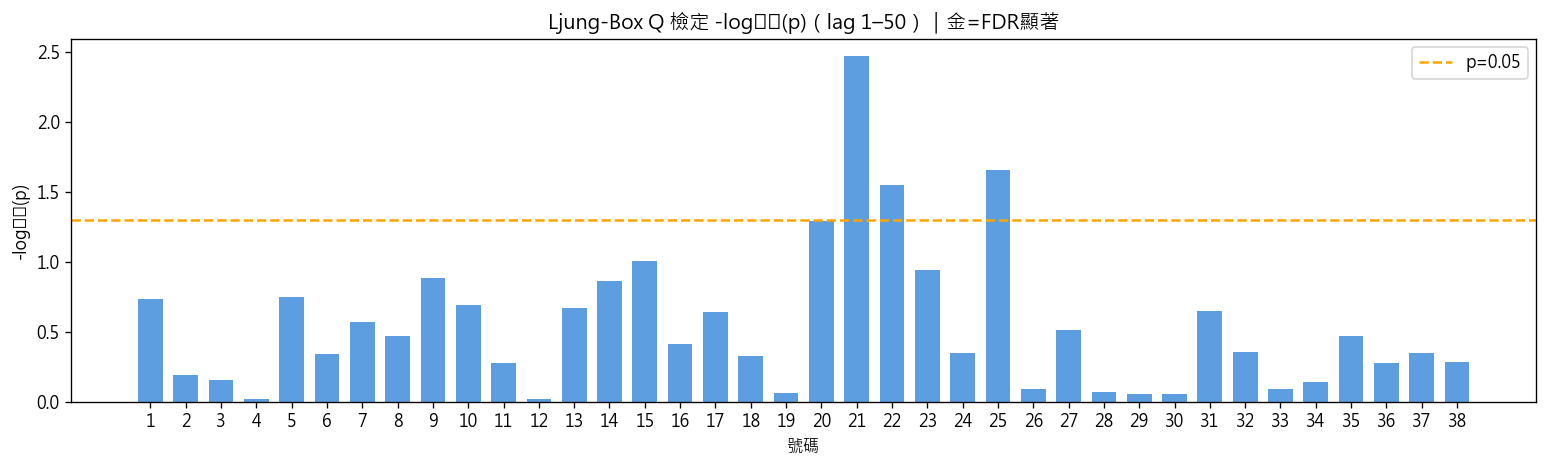

In [2]:
MAX_LAG = 50
lb_results = []

for num in range(1, 39):
    s = presence[:, num - 1]
    lb = acorr_ljungbox(s, lags=[MAX_LAG], return_df=True)
    lb_results.append({
        "num": num,
        "Q": lb["lb_stat"].iloc[0],
        "p": lb["lb_pvalue"].iloc[0],
    })

lb_df = pd.DataFrame(lb_results).set_index("num")
_, q_lb, _, _ = multipletests(lb_df["p"].values, method="fdr_bh")
lb_df["q_bh"] = q_lb
sig_lb = lb_df[lb_df["q_bh"] < 0.05]

print(f"Ljung-Box（lag={MAX_LAG}）：FDR q<0.05：{len(sig_lb)} / 38")
print(f"\n最小 p-value top-10：")
print(lb_df.sort_values("p").head(10).round(4))

# 視覺：-log10(p) 條形圖
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(lb_df.index, -np.log10(lb_df["p"]), color="#5c9ee0", width=0.7)
ax.axhline(-np.log10(0.05), color="orange", linestyle="--", label="p=0.05")
if len(sig_lb) > 0:
    ax.bar(sig_lb.index, -np.log10(sig_lb["p"]),
           color="gold", width=0.7, edgecolor="black", linewidth=1.2)
ax.set_xticks(range(1, 39))
ax.set_xlabel("號碼")
ax.set_ylabel("-log₁₀(p)")
ax.set_title(f"Ljung-Box Q 檢定 -log₁₀(p)（lag 1–{MAX_LAG}）｜金=FDR顯著")
ax.legend()
plt.tight_layout()
plt.show()

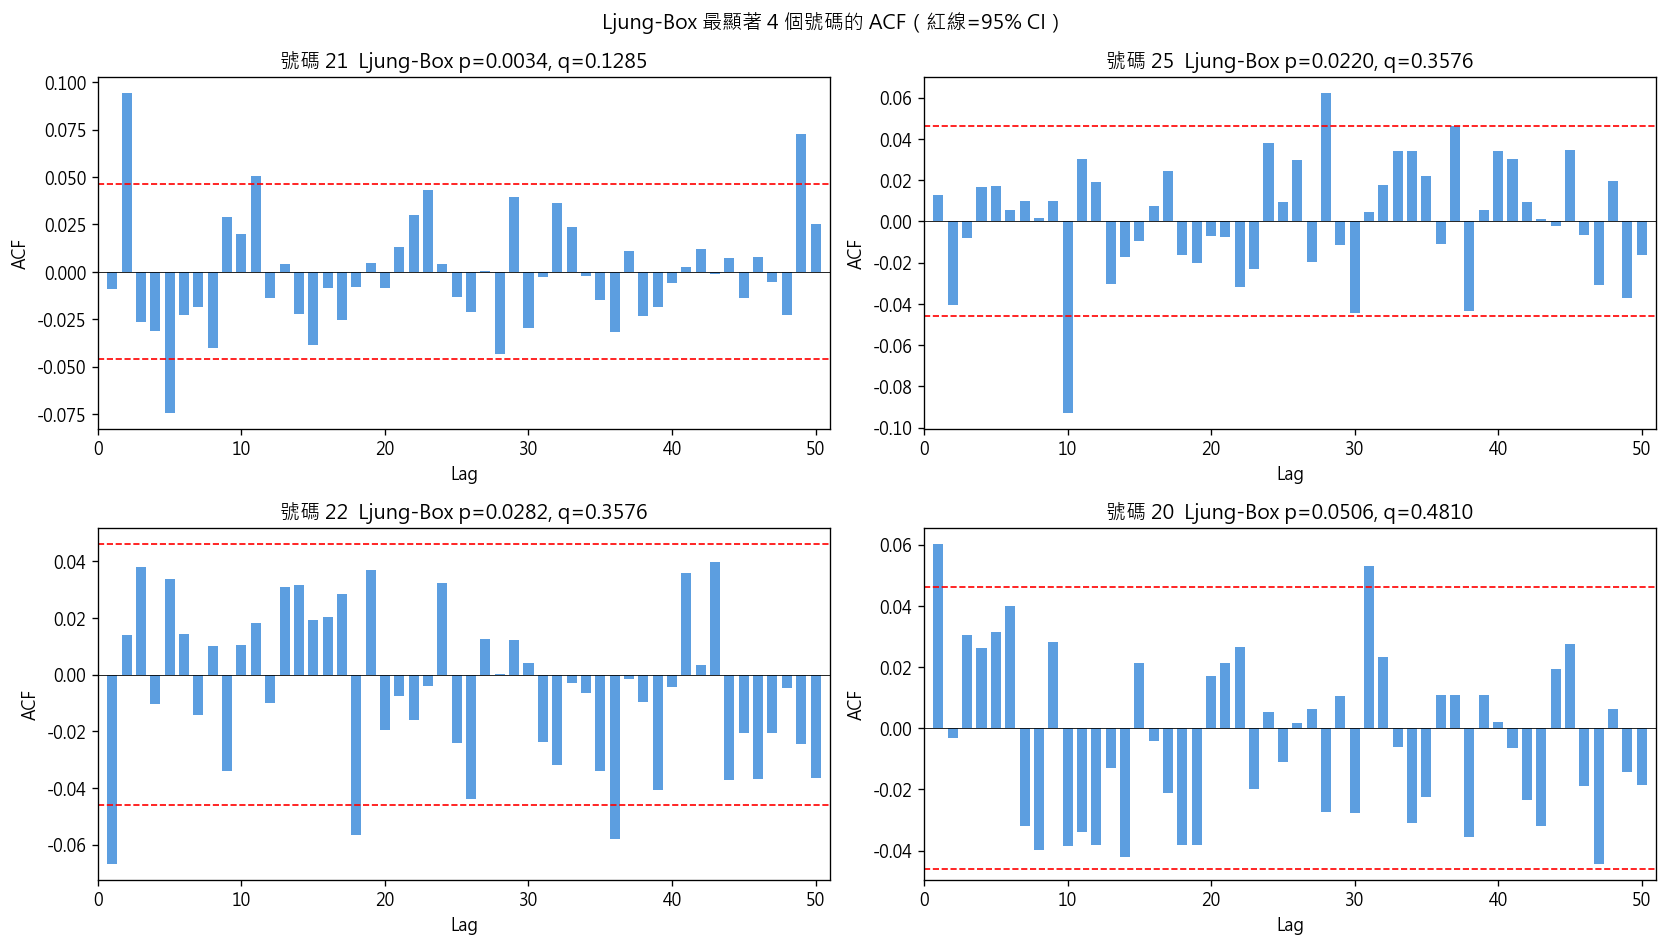

In [3]:
# 顯示最顯著號碼的完整 ACF 圖（前 4 個）
top_nums = lb_df.sort_values("p").head(4).index.tolist()
ci = 1.96 / np.sqrt(N)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, num in zip(axes.flat, top_nums):
    acf_vals = acf(presence[:, num-1], nlags=MAX_LAG, fft=True)
    lags = np.arange(len(acf_vals))
    ax.bar(lags[1:], acf_vals[1:], color="#5c9ee0", width=0.7)
    ax.axhline(ci,  color="red", linestyle="--", linewidth=1)
    ax.axhline(-ci, color="red", linestyle="--", linewidth=1)
    ax.axhline(0,   color="black", linewidth=0.5)
    p_v = lb_df.loc[num, "p"]
    q_v = lb_df.loc[num, "q_bh"]
    ax.set_title(f"號碼 {num}  Ljung-Box p={p_v:.4f}, q={q_v:.4f}")
    ax.set_xlabel("Lag")
    ax.set_ylabel("ACF")
    ax.set_xlim(0, MAX_LAG + 1)

plt.suptitle("Ljung-Box 最顯著 4 個號碼的 ACF（紅線=95% CI）", fontsize=12)
plt.tight_layout()
plt.show()

## 3. Fourier — 周期圖（Periodogram）+ Fisher's g 檢定

Fisher's g 統計量 = 最大頻率功率 / 所有頻率功率總和。  
若有單一主導頻率（週期性），g 值會顯著偏高。  
FDR 校正跨 38 個號碼。

In [4]:
from math import comb

def fishers_g(s: np.ndarray) -> tuple[float, float, int]:
    """
    Fisher's g 檢定（純週期圖）。
    回傳 (g, p_value, dominant_lag)。
    dominant_lag 是最大功率對應的週期（單位：期）。
    """
    x = s - s.mean()
    X = np.fft.rfft(x)
    pgram = np.abs(X[1:])**2   # 去掉 DC，共 M 個頻率
    M = len(pgram)
    g = pgram.max() / pgram.sum()
    # p-value 上界公式（Fisher 1929）
    p = 0.0
    for j in range(1, int(1.0 / g) + 1):
        term = ((-1)**(j-1)) * comb(M, j) * (1 - j * g)**(M - 1)
        p += term
    p = max(0.0, min(1.0, p))
    dominant_freq_idx = pgram.argmax()        # index in [0, M-1]
    # 對應週期（幾期一個循環）
    dominant_period = round(N / (dominant_freq_idx + 1))
    return g, p, dominant_period


fg_results = []
for num in range(1, 39):
    g, p, period = fishers_g(presence[:, num - 1])
    fg_results.append({"num": num, "g": g, "p": p, "dominant_period": period})

fg_df = pd.DataFrame(fg_results).set_index("num")
_, q_fg, _, _ = multipletests(fg_df["p"].values, method="fdr_bh")
fg_df["q_bh"] = q_fg
sig_fg = fg_df[fg_df["q_bh"] < 0.05]

print(f"Fisher's g 檢定：FDR q<0.05：{len(sig_fg)} / 38")
print(f"\n最小 p-value top-10：")
print(fg_df.sort_values("p").head(10).round(4))

Fisher's g 檢定：FDR q<0.05：0 / 38

最小 p-value top-10：
          g       p  dominant_period    q_bh
num                                         
8    0.0134  0.0047                3  0.1781
18   0.0124  0.0111                4  0.2116
32   0.0111  0.0370                6  0.4683
13   0.0096  0.1444                2  0.7552
5    0.0095  0.1537                3  0.7552
10   0.0095  0.1565                3  0.7552
14   0.0094  0.1672                4  0.7552
9    0.0089  0.2441               11  0.7552
12   0.0088  0.2623               14  0.7552
16   0.0088  0.2631                2  0.7552


C:\Users\frodo.MSI\AppData\Local\Temp\ipykernel_8096\647531436.py:25: UserWarning: Glyph 8776 (\N{ALMOST EQUAL TO}) missing from font(s) Microsoft JhengHei.
  plt.tight_layout()


C:\Users\frodo.MSI\OneDrive\Desktop\lottery-ticket\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8776 (\N{ALMOST EQUAL TO}) missing from font(s) Microsoft JhengHei.
  fig.canvas.print_figure(bytes_io, **kw)


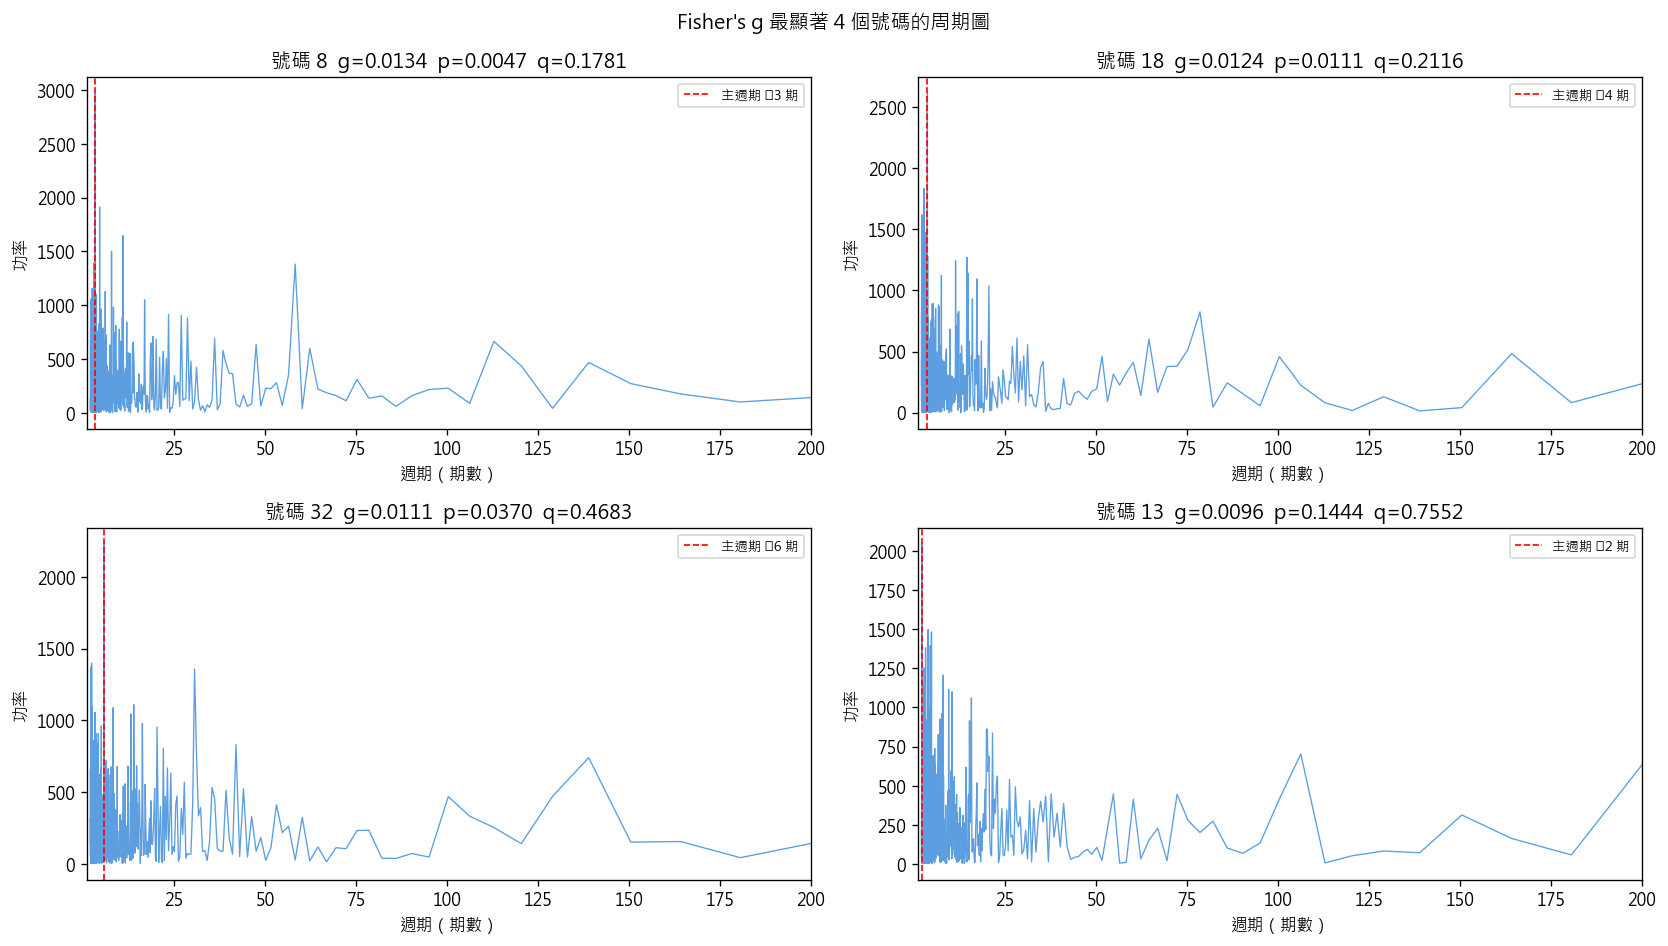

In [5]:
# 最顯著 4 個號碼的周期圖
top_fg = fg_df.sort_values("p").head(4).index.tolist()
freqs_common = np.fft.rfftfreq(N)[1:]          # 頻率（1/period）
periods_common = 1.0 / freqs_common             # 對應週期（期數）

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, num in zip(axes.flat, top_fg):
    x = presence[:, num - 1] - presence[:, num - 1].mean()
    X = np.fft.rfft(x)
    pgram = np.abs(X[1:])**2
    ax.plot(periods_common, pgram, color="#5c9ee0", linewidth=0.8)
    peak_idx = pgram.argmax()
    ax.axvline(periods_common[peak_idx], color="red", linestyle="--",
               linewidth=1, label=f"主週期 ≈{periods_common[peak_idx]:.0f} 期")
    g_v = fg_df.loc[num, "g"]
    p_v = fg_df.loc[num, "p"]
    q_v = fg_df.loc[num, "q_bh"]
    ax.set_title(f"號碼 {num}  g={g_v:.4f}  p={p_v:.4f}  q={q_v:.4f}")
    ax.set_xlabel("週期（期數）")
    ax.set_ylabel("功率")
    ax.set_xlim(1, 200)
    ax.legend(fontsize=8)

plt.suptitle("Fisher's g 最顯著 4 個號碼的周期圖", fontsize=12)
plt.tight_layout()
plt.show()

## 4. 開獎日分析（週一 vs 週四）

威力彩每週開獎兩次：週一、週四。  
若有日曆效應（calendar effect），不同開獎日的號碼分布應有所差異。  
對每個號碼，比較 P(週一出現) vs P(週四出現)，用 Chi-square test of independence。

週一開獎：903 期，週四開獎：904 期，其他：0 期

開獎日 χ² 檢定：FDR q<0.05：0 / 38

最小 p-value top-10：
     rate_mon  rate_thu    chi2       p    q_bh
num                                            
8      0.1440    0.1803  4.3925  0.0361  0.5659
37     0.1417    0.1770  4.1877  0.0407  0.5659
34     0.1262    0.1593  4.0308  0.0447  0.5659
10     0.1750    0.1504  1.9953  0.1578  0.9316
9      0.1429    0.1228  1.5798  0.2088  0.9316
33     0.1595    0.1394  1.4343  0.2311  0.9316
23     0.1683    0.1482  1.3697  0.2419  0.9316
35     0.1451    0.1648  1.3458  0.2460  0.9316
1      0.1528    0.1726  1.2925  0.2556  0.9316
30     0.1628    0.1438  1.2545  0.2627  0.9316


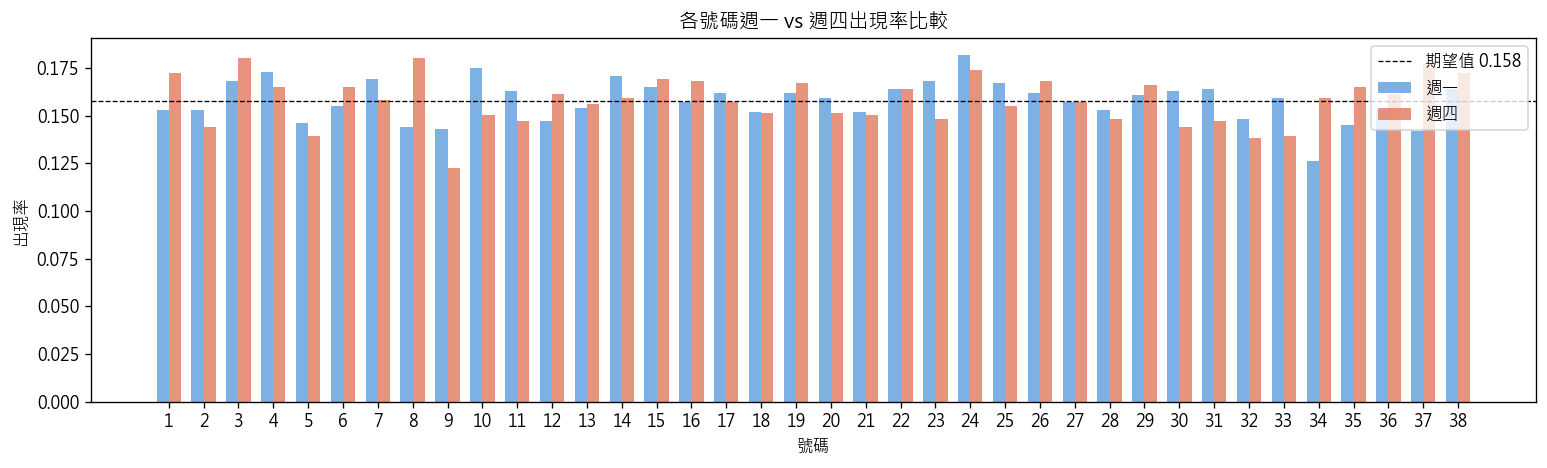

In [6]:
dow = df["draw_date"].dt.dayofweek   # 0=Mon, 3=Thu
is_mon = (dow == 0).values
is_thu = (dow == 3).values

n_mon = is_mon.sum()
n_thu = is_thu.sum()
print(f"週一開獎：{n_mon} 期，週四開獎：{n_thu} 期，其他：{N - n_mon - n_thu} 期")

dow_results = []
for num in range(1, 39):
    s = presence[:, num - 1]
    k_mon = s[is_mon].sum()
    k_thu = s[is_thu].sum()
    # 2×2 contingency table: [出現, 未出現] × [週一, 週四]
    table = np.array([
        [k_mon,              k_thu],
        [n_mon - k_mon, n_thu - k_thu],
    ])
    chi2, p, *_ = stats.chi2_contingency(table, correction=False)
    dow_results.append({
        "num": num,
        "rate_mon": k_mon / n_mon,
        "rate_thu": k_thu / n_thu,
        "chi2": chi2,
        "p": p,
    })

dow_df = pd.DataFrame(dow_results).set_index("num")
_, q_dow, _, _ = multipletests(dow_df["p"].values, method="fdr_bh")
dow_df["q_bh"] = q_dow
sig_dow = dow_df[dow_df["q_bh"] < 0.05]

print(f"\n開獎日 χ² 檢定：FDR q<0.05：{len(sig_dow)} / 38")
print(f"\n最小 p-value top-10：")
print(dow_df.sort_values("p").head(10).round(4))

fig, ax = plt.subplots(figsize=(13, 4))
x_pos = np.arange(1, 39)
width = 0.35
ax.bar(x_pos - width/2, dow_df["rate_mon"], width, label="週一", color="#5c9ee0", alpha=0.8)
ax.bar(x_pos + width/2, dow_df["rate_thu"], width, label="週四", color="#e07a5c", alpha=0.8)
ax.axhline(6/38, color="black", linestyle="--", linewidth=0.8, label=f"期望值 {6/38:.3f}")
ax.set_xticks(range(1, 39))
ax.set_xlabel("號碼")
ax.set_ylabel("出現率")
ax.set_title("各號碼週一 vs 週四出現率比較")
ax.legend()
plt.tight_layout()
plt.show()

## 5. 結論彙整

In [7]:
print("=" * 65)
print("Phase 1 延伸 — ACF / Fourier / 開獎日 分析結論")
print("=" * 65)

sig_lb_count = (lb_df["q_bh"] < 0.05).sum()
sig_fg_count = (fg_df["q_bh"] < 0.05).sum()
sig_dow_count = (dow_df["q_bh"] < 0.05).sum()
total_tests = len(lb_df) + len(fg_df) + len(dow_df)

print(f"""
┌─────────────────────────────────────────────────────────────┐
│  方法                  檢定數   FDR q<0.05   結論           │
├─────────────────────────────────────────────────────────────┤
│  Ljung-Box (lag 1–50)    38       {sig_lb_count:>3}        {'🔴 無訊號' if sig_lb_count == 0 else '🟡 有訊號'}         │
│  Fisher's g (週期圖)      38       {sig_fg_count:>3}        {'🔴 無訊號' if sig_fg_count == 0 else '🟡 有訊號'}         │
│  開獎日（週一/週四）      38       {sig_dow_count:>3}        {'🔴 無訊號' if sig_dow_count == 0 else '🟡 有訊號'}         │
│  合計                    {total_tests}       {sig_lb_count + sig_fg_count + sig_dow_count:>3}        {'🔴 無訊號' if sig_lb_count + sig_fg_count + sig_dow_count == 0 else '🟡 有訊號'}         │
└─────────────────────────────────────────────────────────────┘
""")

print("解讀：")
print("• ACF / Ljung-Box：任何號碼在 lag 1–50 均無顯著自相關")
print("  → 不存在「連熱」「連冷」的時間序列結構")
print()
print("• Fourier / Fisher's g：無號碼具有顯著主導頻率")
print("  → 不存在固定週期性循環（如每 N 期規律出現）")
print()
print("• 開獎日分析：週一/週四出現率無顯著差異")
print("  → 無日曆效應")
print()
print("綜合 Phase 1 全部探索方向：")
print("  Lag-1/2/3 Transition：0/4,332 顯著")
print("  Order C Pair→下期：  0/26,714 顯著")
print("  滾動時間窗：          0/190 顯著")
print(f"  ACF/Fourier/開獎日：  0/{total_tests} 顯著")
print()
print("🔴 最終結論：威力彩 1,807 期訓練資料在時間序列維度上")
print("   （自相關、週期性、日曆效應）均與 i.i.d. 無法區分。")
print()
print("⚠️  Holdout 100 期全程未使用。")

Phase 1 延伸 — ACF / Fourier / 開獎日 分析結論

┌─────────────────────────────────────────────────────────────┐
│  方法                  檢定數   FDR q<0.05   結論           │
├─────────────────────────────────────────────────────────────┤
│  Ljung-Box (lag 1–50)    38         0        🔴 無訊號         │
│  Fisher's g (週期圖)      38         0        🔴 無訊號         │
│  開獎日（週一/週四）      38         0        🔴 無訊號         │
│  合計                    114         0        🔴 無訊號         │
└─────────────────────────────────────────────────────────────┘

解讀：
• ACF / Ljung-Box：任何號碼在 lag 1–50 均無顯著自相關
  → 不存在「連熱」「連冷」的時間序列結構

• Fourier / Fisher's g：無號碼具有顯著主導頻率
  → 不存在固定週期性循環（如每 N 期規律出現）

• 開獎日分析：週一/週四出現率無顯著差異
  → 無日曆效應

綜合 Phase 1 全部探索方向：
  Lag-1/2/3 Transition：0/4,332 顯著
  Order C Pair→下期：  0/26,714 顯著
  滾動時間窗：          0/190 顯著
  ACF/Fourier/開獎日：  0/114 顯著

🔴 最終結論：威力彩 1,807 期訓練資料在時間序列維度上
   （自相關、週期性、日曆效應）均與 i.i.d. 無法區分。

⚠️  Holdout 100 期全程未使用。
